 # 06 — Functional Interpretability



 This notebook visualises and interprets the final functional classification

 results without retraining the heavy final models.



 It combines:



 - class-level spectral structure;

 - FPCA and FPLS score-space separation;

 - distance-based nearest-neighbour interpretation;

 - local and global distance contribution curves;

 - functional logistic regression and linear SVM weight functions.



 Main outputs:



 - coefficient and top-weight-region tables;

 - class mean and mean-difference plots;

 - FPCA/FPLS scatter plots;

 - nearest-neighbour interpretation plots;

 - linear-model weight-function plots.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics.pairwise import pairwise_distances

warnings.filterwarnings("ignore")



 ## 1. General configuration



 This section defines paths, column names, class labels, and other constants.



 - `DATA_DIR` contains the original sampled spectra.

 - `FINAL_RESULTS_DIR` contains the saved interpretability payload from the

   final modelling notebook.

 - `OUT_DIR` stores the interpretability tables and figures.

 - `CLASS_NAME_MAP` controls how class labels are shown in figures.

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "og_data"

FINAL_RESULTS_DIR = BASE_DIR / "results" / "04_final_functional_models"
OUT_DIR = BASE_DIR / "results" / "06_interpretability"
OUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = DATA_DIR / "xp_sampled_spectra.csv"
FINAL_PAYLOAD_FILE = FINAL_RESULTS_DIR / "interpretability_payload.npz"

TARGET_COL = "y"
SOURCE_ID_COL = "source_id"

CLASS_NAME_MAP = {
    0: "Nedvinarė",
    1: "Dvinarė",
}

MODEL_NAME_MAP = {
    "logreg": "Funkcinė logistinė regresija",
    "svm": "Funkcinis tiesinis SVM",
}

RAW_LABEL = "Neapdoroti duomenys"



 ## 2. Plot style



 This section defines a consistent thesis-ready visual style. The same colors,

 font sizes, and axis formatting are used across all interpretability figures.

In [3]:
COLOR_PRIMARY = "#104A7E"
COLOR_SECONDARY = "#78003F"
COLOR_DARK = "#0D1530"
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

SMOOTH_COLORS = {
    0.0: "#4A4A4A",
    2.0: "#6193CD",
    4.0: "#8DB3E2",
    6.0: "#B7D0EE",
}

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.edgecolor": "#444444",
        "axes.linewidth": 0.8,
        "axes.labelcolor": COLOR_TEXT,
        "xtick.color": COLOR_TEXT,
        "ytick.color": COLOR_TEXT,
        "text.color": COLOR_TEXT,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)



 ## 3. Helper functions



 These functions handle repeated tasks such as row-wise L2 normalisation,

 wavelength-column detection, nearest-neighbour contribution calculation,

 and figure saving.

In [4]:
def apply_clean_axes(
    ax,
    add_grid: bool = False,
    grid_axis: str = "y",
) -> None:
    """Apply clean thesis-style formatting to a matplotlib axis.

    Parameters
    ----------
    ax:
        Matplotlib axis object.
    add_grid:
        Whether to add a light dashed grid.
    grid_axis:
        Axis along which the grid should be drawn.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if add_grid:
        ax.grid(
            True,
            axis=grid_axis,
            linestyle="--",
            linewidth=0.6,
            alpha=0.5,
            color=COLOR_LIGHT,
        )
    else:
        ax.grid(False)


def show_and_save(fig, path: Path) -> None:
    """Show a figure and immediately save it as an SVG file.

    This keeps the figure export next to the plotting block and removes the
    need for a separate figure-saving section.

    Parameters
    ----------
    fig:
        Matplotlib figure object.
    path:
        Output SVG path.
    """
    plt.tight_layout()
    plt.show()
    fig.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close(fig)


def l2_normalise_rows(X: np.ndarray) -> np.ndarray:
    """Apply row-wise L2 normalisation.

    Each spectrum is divided by its L2 norm. Rows with zero norm are protected
    from division by zero.

    Parameters
    ----------
    X:
        Input matrix where rows are spectra and columns are wavelengths.

    Returns
    -------
    np.ndarray
        L2-normalised matrix.
    """
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)

    return X / norms


def normalise_curve_for_plot(beta: np.ndarray) -> np.ndarray:
    """Scale a curve by its maximum absolute value.

    This is useful when curves have different numerical scales but should be
    compared visually by shape.

    Parameters
    ----------
    beta:
        Input curve.

    Returns
    -------
    np.ndarray
        Curve scaled to approximately `[-1, 1]`.
    """
    max_abs = np.max(np.abs(beta))

    if max_abs == 0:
        return beta

    return beta / max_abs


def infer_wavelength_columns(df: pd.DataFrame) -> list[str]:
    """Infer spectral columns from a sampled spectra dataframe.

    The function first looks for columns named `wl_*`. If these are not found,
    it tries columns named `flux_*`.

    Parameters
    ----------
    df:
        Input dataframe.

    Returns
    -------
    list[str]
        Sorted spectral column names.

    Raises
    ------
    ValueError
        If no spectral columns are found.
    """
    wl_cols = [col for col in df.columns if col.startswith("wl_")]

    if wl_cols:
        return sorted(wl_cols, key=lambda col: float(col.split("_")[1]))

    flux_cols = [col for col in df.columns if col.startswith("flux_")]

    if flux_cols:
        return sorted(flux_cols, key=lambda col: int(col.split("_")[1]))

    raise ValueError(
        "Could not find spectral columns. "
        "Expected columns like `wl_336` or `flux_0`."
    )


def build_global_knn_contribution(
    X: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Calculate average nearest-neighbour distance contribution.

    For each object, the nearest neighbour is found using Euclidean distance.
    The absolute wavelength-wise difference between each object and its nearest
    neighbour is then averaged across the dataset.

    Parameters
    ----------
    X:
        L2-normalised spectra matrix.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Mean absolute wavelength-wise differences and nearest-neighbour indices.
    """
    distances = pairwise_distances(X, X, metric="euclidean")
    np.fill_diagonal(distances, np.inf)

    nearest_idx = np.argmin(distances, axis=1)
    all_abs_diffs = np.abs(X - X[nearest_idx])

    return all_abs_diffs.mean(axis=0), nearest_idx


def top_weight_regions(
    wavelengths: np.ndarray,
    weights: np.ndarray,
    top_n: int = 15,
    weight_name: str = "weight",
) -> pd.DataFrame:
    """Return wavelengths with the largest absolute model weights.

    Parameters
    ----------
    wavelengths:
        Wavelength grid.
    weights:
        Model coefficient or weight curve.
    top_n:
        Number of strongest wavelength regions to return.
    weight_name:
        Name used for the weight column.

    Returns
    -------
    pd.DataFrame
        Table of top absolute-weight wavelength regions.
    """
    weight_df = pd.DataFrame(
        {
            "wavelength": wavelengths,
            weight_name: weights,
            f"abs_{weight_name}": np.abs(weights),
        }
    )

    return weight_df.nlargest(top_n, f"abs_{weight_name}").reset_index(
        drop=True,
    )


def safe_model_key(model_name: str) -> str:
    """Convert a model name into a safe payload key.

    Parameters
    ----------
    model_name:
        Human-readable model name.

    Returns
    -------
    str
        Lowercase string safe for payload key construction.
    """
    return (
        model_name.lower()
        .replace(" + ", "_")
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("=", "_")
        .replace(".", "_")
        .replace("-", "_")
    )


def extract_weight_curve_from_payload(
    payload,
    model_name: str,
) -> np.ndarray:
    """Extract a model weight curve from a NumPy payload.

    Parameters
    ----------
    payload:
        Loaded `.npz` payload.
    model_name:
        Human-readable model name.

    Returns
    -------
    np.ndarray
        Extracted model weight curve.

    Raises
    ------
    KeyError
        If the expected weight key is not present in the payload.
    """
    key = f"weights_{safe_model_key(model_name)}"

    if key not in payload.files:
        raise KeyError(f"Missing weight curve in payload: {key}")

    return payload[key]


def sigma_label(sigma: float) -> str:
    """Format a smoothing parameter for plot labels.

    Parameters
    ----------
    sigma:
        Gaussian smoothing parameter.

    Returns
    -------
    str
        Label for the smoothing setting.
    """
    return "Raw" if float(sigma) == 0.0 else f"σ={sigma:.1f}"



 ## 4. Load dataset and interpretability payload



 The original spectra are loaded from `xp_sampled_spectra.csv`. The saved

 interpretability payload provides arrays produced in the final modelling

 notebook, including class means, FPCA/FPLS scores, nearest-neighbour example,

 and linear-model coefficients.

In [5]:
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

if not FINAL_PAYLOAD_FILE.exists():
    raise FileNotFoundError(
        f"Final interpretability payload not found: {FINAL_PAYLOAD_FILE}"
    )

df = pd.read_csv(INPUT_FILE)
final_payload = np.load(FINAL_PAYLOAD_FILE)

wl_cols = infer_wavelength_columns(df)

wavelengths_from_df = np.array(
    [float(col.split("_")[1]) for col in wl_cols],
    dtype=float,
)

X_raw_original = df[wl_cols].to_numpy(dtype=float)
X_l2 = l2_normalise_rows(X_raw_original)

wavelengths = (
    final_payload["wavelengths"]
    if "wavelengths" in final_payload.files
    else wavelengths_from_df
)

y = final_payload["y"]

mean_0 = final_payload["mean_0"]
mean_1 = final_payload["mean_1"]
diff_10 = final_payload["diff_10"]

scores_fpca = final_payload["scores_fpca"]
scores_fpls = final_payload["scores_fpls"]

x_query = final_payload["x_query"]
closest_curve = final_payload["closest_curve"]
abs_diff = final_payload["abs_diff"]

beta_logreg = final_payload["beta_logreg"]
beta_svm = final_payload["beta_svm"]

mean_distance_contribution, nearest_idx = build_global_knn_contribution(X_l2)

print("Loaded dataset shape:", df.shape)
print("Loaded final payload successfully.")
print("Number of wavelength bins:", len(wavelengths))



Loaded dataset shape: (2815, 345)
Loaded final payload successfully.
Number of wavelength bins: 343


 ## 5. Rebuild nearest-neighbour context



 The payload stores the query spectrum and its closest neighbour curve. This

 section matches them back to rows in the original dataframe so that source IDs

 and labels can be reported.

In [6]:
query_match = np.argmin(
    np.sum((X_l2 - x_query.reshape(1, -1)) ** 2, axis=1)
)
nn_match = np.argmin(
    np.sum((X_l2 - closest_curve.reshape(1, -1)) ** 2, axis=1)
)

query_label = int(y[query_match])
nn_label = int(y[nn_match])

query_label_name = CLASS_NAME_MAP.get(query_label, str(query_label))
nn_label_name = CLASS_NAME_MAP.get(nn_label, str(nn_label))

query_source_id = (
    df.iloc[query_match][SOURCE_ID_COL]
    if SOURCE_ID_COL in df.columns
    else np.nan
)

nn_source_id = (
    df.iloc[nn_match][SOURCE_ID_COL]
    if SOURCE_ID_COL in df.columns
    else np.nan
)

nn_table = pd.DataFrame(
    {
        "query_index": [query_match],
        "query_source_id": [query_source_id],
        "query_label": [query_label],
        "query_label_name": [query_label_name],
        "neighbour_index": [nn_match],
        "neighbour_source_id": [nn_source_id],
        "neighbour_label": [nn_label],
        "neighbour_label_name": [nn_label_name],
        "euclidean_distance": [float(np.linalg.norm(x_query - closest_curve))],
    }
)

display(nn_table)



,query_index,query_source_id,query_label,query_label_name,neighbour_index,neighbour_source_id,neighbour_label,neighbour_label_name,euclidean_distance
0,47,1.465880e+17,1,Dvinarė,2399,6.381104e+18,1,Dvinarė,0.047313


 ## 6. Coefficient diagnostics



 This section creates coefficient tables for functional logistic regression and

 linear SVM. It also extracts the wavelength regions with the largest absolute

 model weights.

In [7]:
coef_df_raw = pd.DataFrame(
    {
        "wavelength": wavelengths,
        "beta_logreg_raw": beta_logreg,
        "beta_svm_raw": beta_svm,
        "abs_beta_logreg_raw": np.abs(beta_logreg),
        "abs_beta_svm_raw": np.abs(beta_svm),
    }
)

top_logreg = top_weight_regions(
    wavelengths=wavelengths,
    weights=beta_logreg,
    top_n=15,
    weight_name="beta_logreg_raw",
)

top_svm = top_weight_regions(
    wavelengths=wavelengths,
    weights=beta_svm,
    top_n=15,
    weight_name="beta_svm_raw",
)

print("\n=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINĖ LOGISTINĖ REGRESIJA ===")
display(top_logreg)

print("\n=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINIS TIESINIS SVM ===")
display(top_svm)




=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINĖ LOGISTINĖ REGRESIJA ===


,wavelength,beta_logreg_raw,abs_beta_logreg_raw
0,1020.0,0.145990,0.145990
1,1000.0,0.141776,0.141776
2,998.0,0.141642,0.141642
3,972.0,0.140373,0.140373
4,974.0,0.138672,0.138672
5,996.0,0.138409,0.138409
6,970.0,0.137382,0.137382
7,1002.0,0.137003,0.137003
8,994.0,0.133204,0.133204
9,976.0,0.132702,0.132702



=== TOP 15 |SVORIŲ| REGIONAI: FUNKCINIS TIESINIS SVM ===


,wavelength,beta_svm_raw,abs_beta_svm_raw
0,1020.0,0.170357,0.170357
1,974.0,0.110800,0.110800
2,972.0,0.110324,0.110324
3,1000.0,0.107294,0.107294
4,976.0,0.104418,0.104418
5,970.0,0.103424,0.103424
6,1002.0,0.103348,0.103348
7,998.0,0.102301,0.102301
8,942.0,0.095136,0.095136
9,944.0,0.094444,0.094444


 ## 7. Plot: class mean spectra



 This figure compares the mean L2-normalised spectrum of each class.

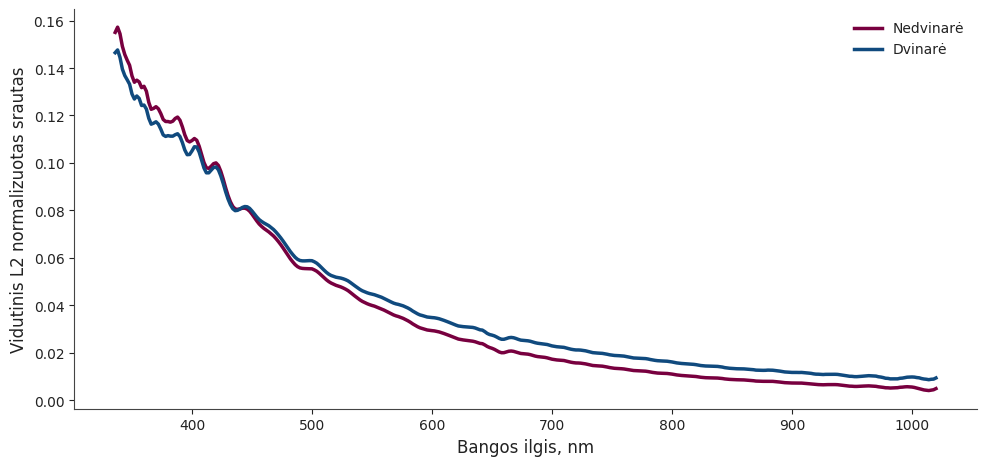

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    mean_0,
    linewidth=2.5,
    color=COLOR_SECONDARY,
    label="Nedvinarė",
)

ax.plot(
    wavelengths,
    mean_1,
    linewidth=2.5,
    color=COLOR_PRIMARY,
    label="Dvinarė",
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_class_mean_spectra_raw.svg")



 ## 8. Plot: mean spectral difference



 This figure shows the binary minus non-binary class mean spectrum.

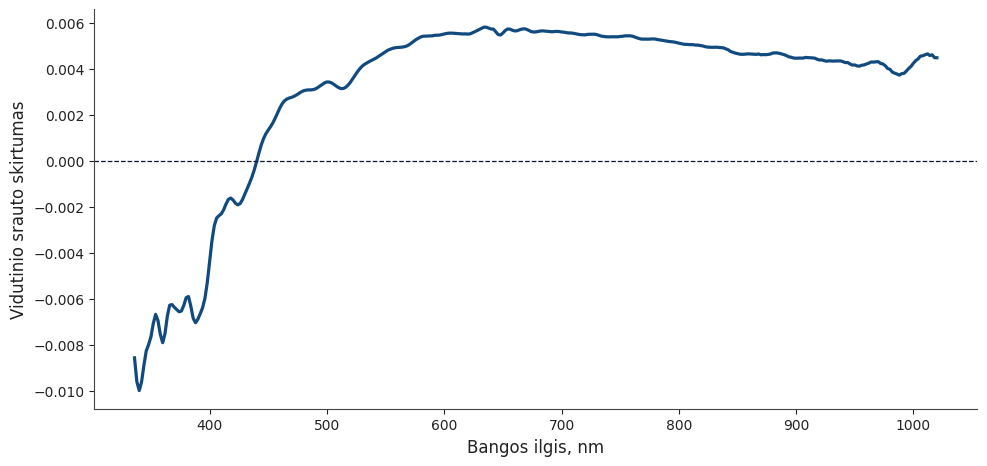

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    diff_10,
    linewidth=2.3,
    color=COLOR_PRIMARY,
)

ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinio srauto skirtumas")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_mean_difference_raw.svg")



 ## 9. Plot: FPCA class separation



 This scatter plot shows objects in the first two FPCA score dimensions.

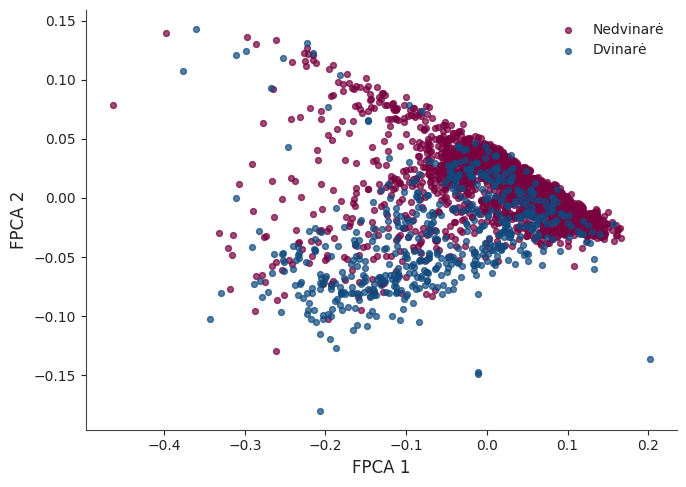

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    scores_fpca[y == 0, 0],
    scores_fpca[y == 0, 1],
    s=18,
    alpha=0.7,
    label="Nedvinarė",
    color=COLOR_SECONDARY,
)

ax.scatter(
    scores_fpca[y == 1, 0],
    scores_fpca[y == 1, 1],
    s=18,
    alpha=0.7,
    label="Dvinarė",
    color=COLOR_PRIMARY,
)

ax.set_xlabel("FPCA 1")
ax.set_ylabel("FPCA 2")
ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_fpca_scatter.svg")



 ## 10. Plot: FPLS class separation



 This scatter plot shows objects in the first two FPLS score dimensions.

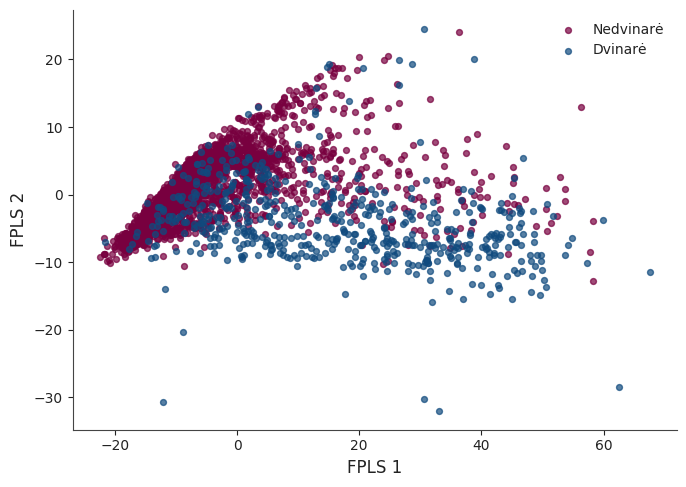

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    scores_fpls[y == 0, 0],
    scores_fpls[y == 0, 1],
    s=18,
    alpha=0.7,
    label="Nedvinarė",
    color=COLOR_SECONDARY,
)

ax.scatter(
    scores_fpls[y == 1, 0],
    scores_fpls[y == 1, 1],
    s=18,
    alpha=0.7,
    label="Dvinarė",
    color=COLOR_PRIMARY,
)

ax.set_xlabel("FPLS 1")
ax.set_ylabel("FPLS 2")
ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_fpls_scatter.svg")



 ## 11. Plot: nearest-neighbour example



 This figure compares one query spectrum with its closest training neighbour.

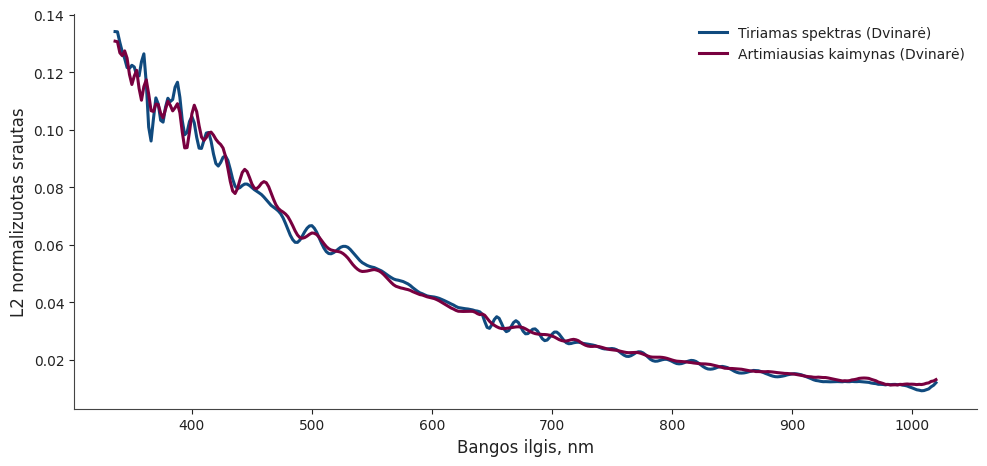

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    x_query,
    linewidth=2.2,
    color=COLOR_PRIMARY,
    label=f"Tiriamas spektras ({query_label_name})",
)

ax.plot(
    wavelengths,
    closest_curve,
    linewidth=2.2,
    color=COLOR_SECONDARY,
    label=f"Artimiausias kaimynas ({nn_label_name})",
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_nearest_neighbour_example.svg")



 ## 12. Plot: local distance contribution



 This figure shows the wavelength-wise absolute difference between the query

 spectrum and its nearest neighbour.

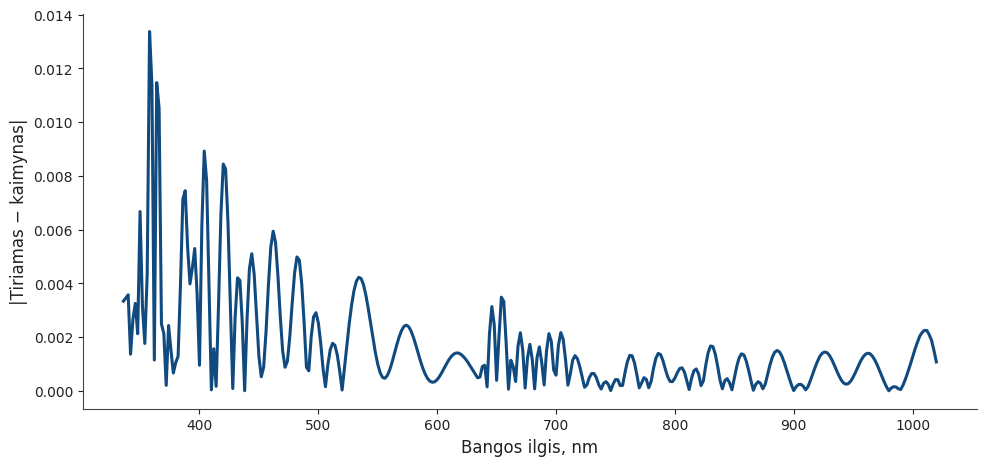

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    abs_diff,
    linewidth=2.2,
    color=COLOR_PRIMARY,
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("|Tiriamas − kaimynas|")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_local_distance_contribution.svg")



 ## 13. Plot: global distance contribution



 This figure shows the average wavelength-wise absolute difference between all

 objects and their nearest neighbours.

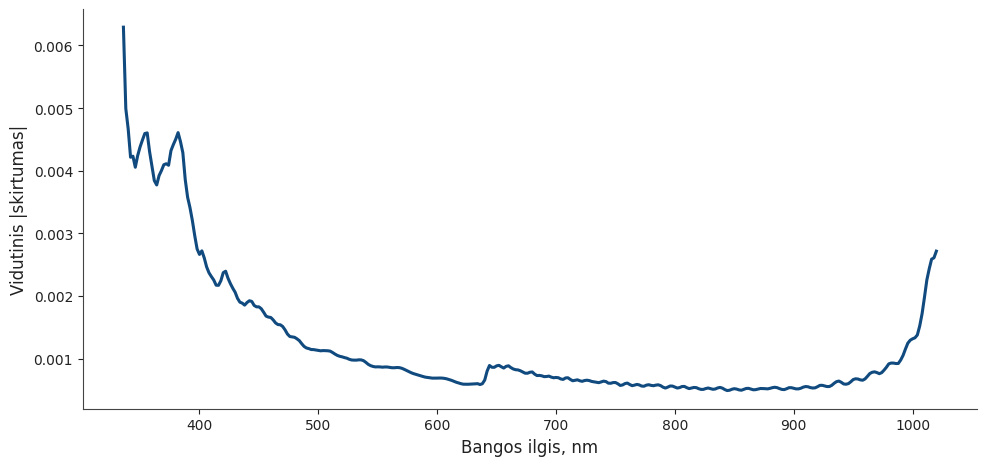

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    mean_distance_contribution,
    linewidth=2.2,
    color=COLOR_PRIMARY,
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidutinis |skirtumas|")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_global_distance_contribution.svg")



 ## 14. Plot: functional logistic regression weight function



 Positive weights favour the binary class, while negative weights favour the

 non-binary class.

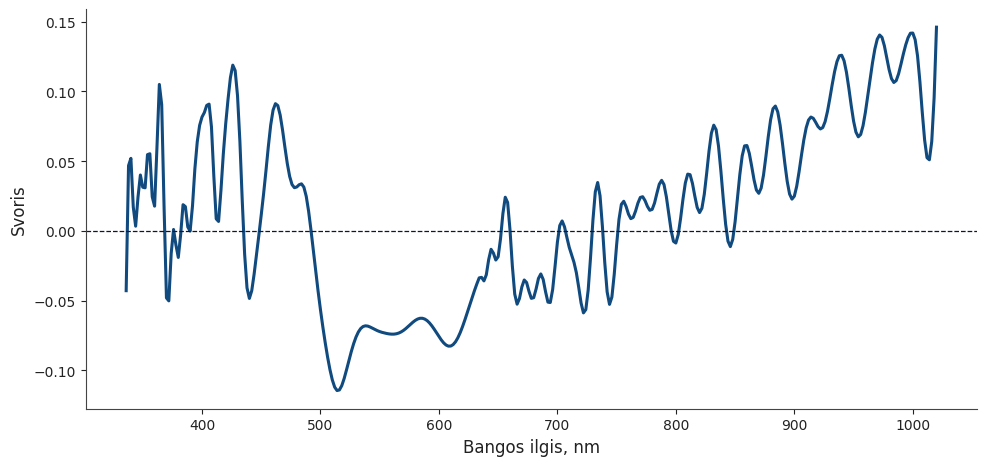

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    beta_logreg,
    linewidth=2.2,
    color=COLOR_PRIMARY,
)

ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_beta_logreg_raw.svg")



 ## 15. Plot: functional linear SVM weight function



 Positive weights favour the binary class, while negative weights favour the

 non-binary class.

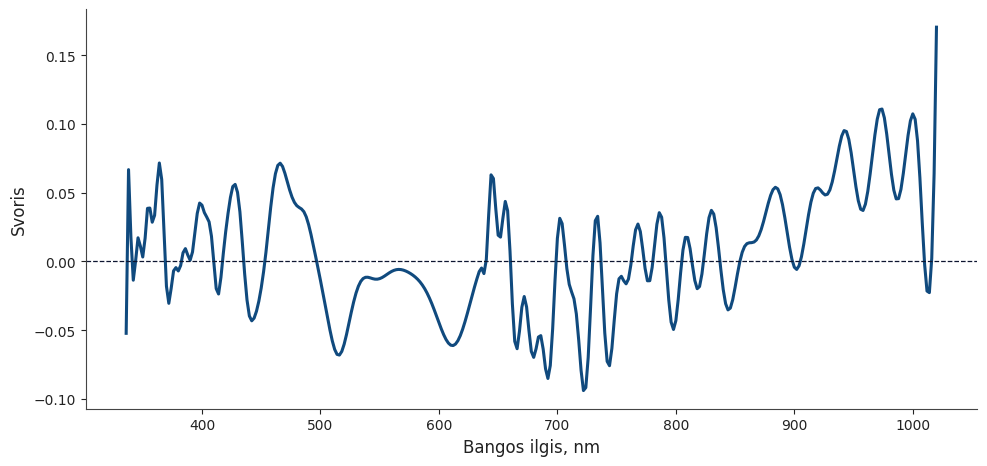

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    beta_svm,
    linewidth=2.2,
    color=COLOR_PRIMARY,
)

ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_beta_svm_raw.svg")



 ## 16. Plot: comparison of linear-model weight functions



 This figure overlays the logistic regression and linear SVM weight curves.

 Filled regions make positive and negative contributions easier to see.

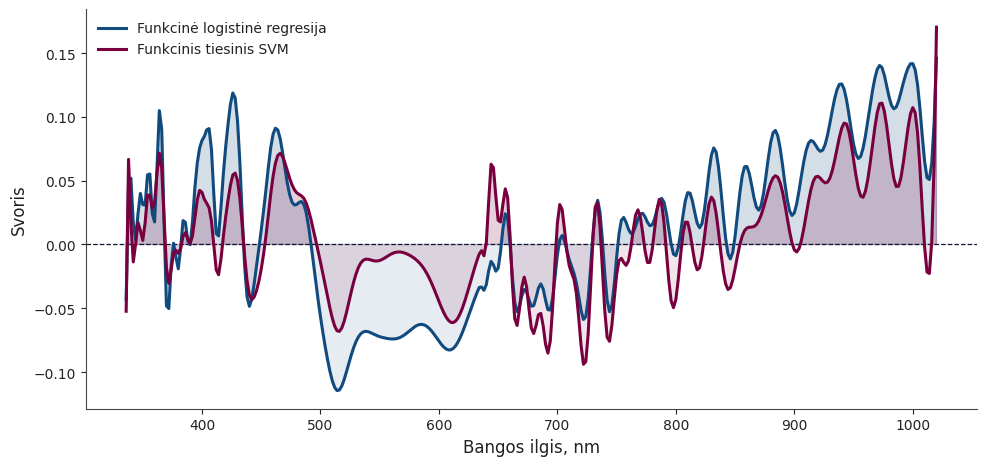

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.8))

# Plot both weight curves in the same wavelength space.
ax.plot(
    wavelengths,
    beta_logreg,
    linewidth=2.2,
    color=COLOR_PRIMARY,
    label="Funkcinė logistinė regresija",
    zorder=3,
)

ax.plot(
    wavelengths,
    beta_svm,
    linewidth=2.2,
    color=COLOR_SECONDARY,
    label="Funkcinis tiesinis SVM",
    zorder=3,
)

# Shade positive and negative logistic-regression weight regions.
ax.fill_between(
    wavelengths,
    beta_logreg,
    0,
    where=(beta_logreg >= 0),
    color=COLOR_PRIMARY,
    alpha=0.18,
    interpolate=True,
    zorder=1,
)

ax.fill_between(
    wavelengths,
    beta_logreg,
    0,
    where=(beta_logreg < 0),
    color=COLOR_PRIMARY,
    alpha=0.10,
    interpolate=True,
    zorder=1,
)

# Shade positive and negative SVM weight regions.
ax.fill_between(
    wavelengths,
    beta_svm,
    0,
    where=(beta_svm >= 0),
    color=COLOR_SECONDARY,
    alpha=0.18,
    interpolate=True,
    zorder=1,
)

ax.fill_between(
    wavelengths,
    beta_svm,
    0,
    where=(beta_svm < 0),
    color=COLOR_SECONDARY,
    alpha=0.10,
    interpolate=True,
    zorder=1,
)

# Add zero reference line for interpretation of weight sign.
ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
    zorder=2,
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)
show_and_save(fig, OUT_DIR / "fig_beta_compare_raw.svg")



 ## 17. Save main tables



 Figures are saved immediately after their plotting blocks. This section saves

 only the CSV table outputs.

In [18]:
coef_df_raw.to_csv(
    OUT_DIR / "coefficient_curves_raw.csv",
    index=False,
)

top_logreg.to_csv(
    OUT_DIR / "top_logreg_regions_raw.csv",
    index=False,
)

top_svm.to_csv(
    OUT_DIR / "top_svm_regions_raw.csv",
    index=False,
)

print("Saved main CSV outputs to:", OUT_DIR)

Saved main CSV outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\06_interpretability
